In [7]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.cluster import OPTICS, cluster_optics_dbscan, DBSCAN
import sklearn.cluster
import hdbscan
import time
import seaborn as sns
%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}
from sklearn.neighbors import NearestNeighbors, RadiusNeighborsClassifier
import networkx as nx
from scipy.spatial import ConvexHull
import sklearn.metrics

In [20]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None, hide=False, figsize=(10, 4)):
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    # Black removed and is used for noise instead.
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # The probability of a point belonging to its labeled cluster determines
    # the size of its marker
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "o" if k != -1 else "" if hide else "x",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else ""
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

In [4]:
day24 = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/o8p_day24_s12_results.csv", index_col="label").drop(columns=["nucleus_percent_touching_1", "nucleus_bounds"]).rename(columns={"nucleus_i":"i", "nucleus_j":"j"})
coords = day24[["i","j"]]
X = coords.values
coords

,i,j
label,,
1,1626.681946,25270.460243
2,1836.065078,22567.976169
3,2330.057076,15284.928851
4,2759.281008,23822.818314
5,2788.794845,23577.046907
...,...,...
4508,39124.704775,18869.474668
4509,39305.602673,20307.226394
4510,39664.264819,23492.662473


In [11]:
nbrs = RadiusNeighborsClassifier(radius=300)
nbrs.fit(X)

TypeError: RadiusNeighborsClassifier.fit() missing 1 required positional argument: 'y'

In [25]:
nbrs = NearestNeighbors(radius=150).fit(coords)
neighbors = nbrs.radius_neighbors(coords, return_distance=False)

G = nx.Graph()
G.add_nodes_from(range(len(day24)))

for i, neighs in enumerate(neighbors):
    for j in neighs:
        if i != j:
            G.add_edge(i, j)

components = list(nx.connected_components(G))

colony_id = {}
for k, comp in enumerate(components):
    for idx in comp:
        colony_id[idx] = k

day24["colony_id_graph"] = day24.index.map(colony_id)

In [33]:
neighbors[9]

array([ 9, 14])

In [28]:
sizes = day24["colony_id_graph"].value_counts()
valid = sizes[sizes >= 10].index  # threshold = 10 cells
valid
day24["colony_id_clean"] = np.where(day24["colony_id_graph"].isin(valid), day24["colony_id_graph"], -1)
day24["in_colony"] = day24["colony_id_graph"].isin(valid)

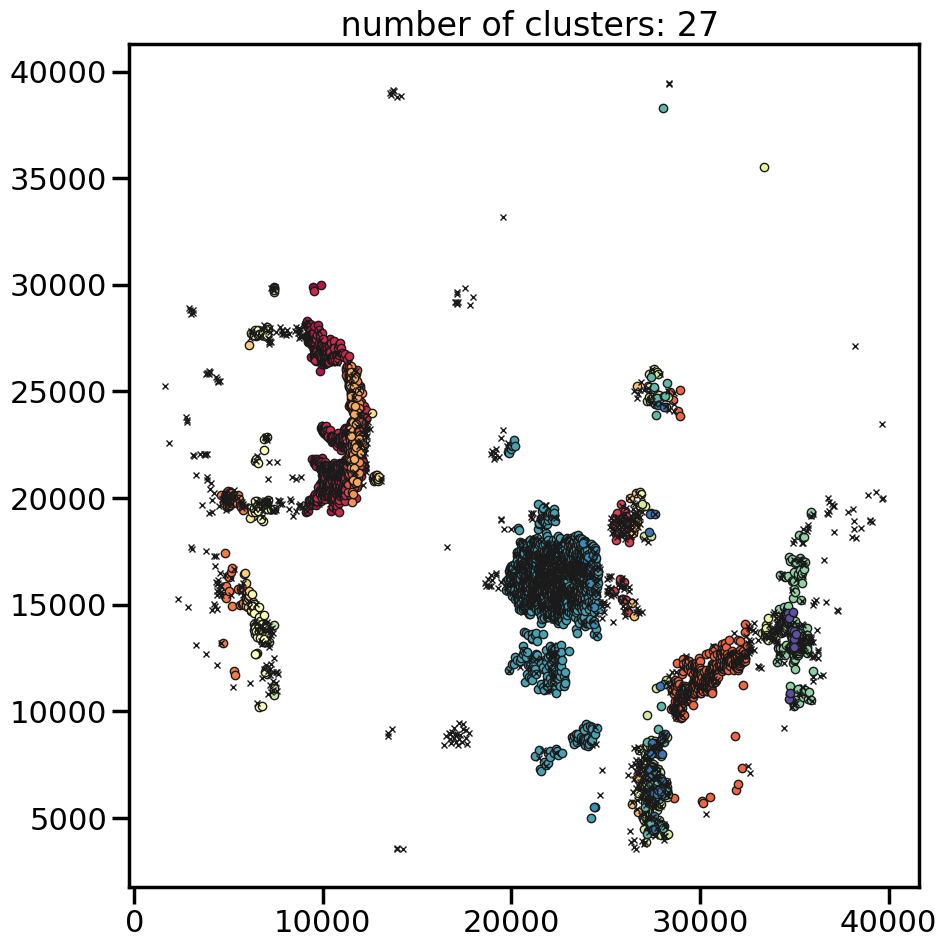

In [29]:
plot(X, day24["colony_id_clean"].values, figsize=(10,10))

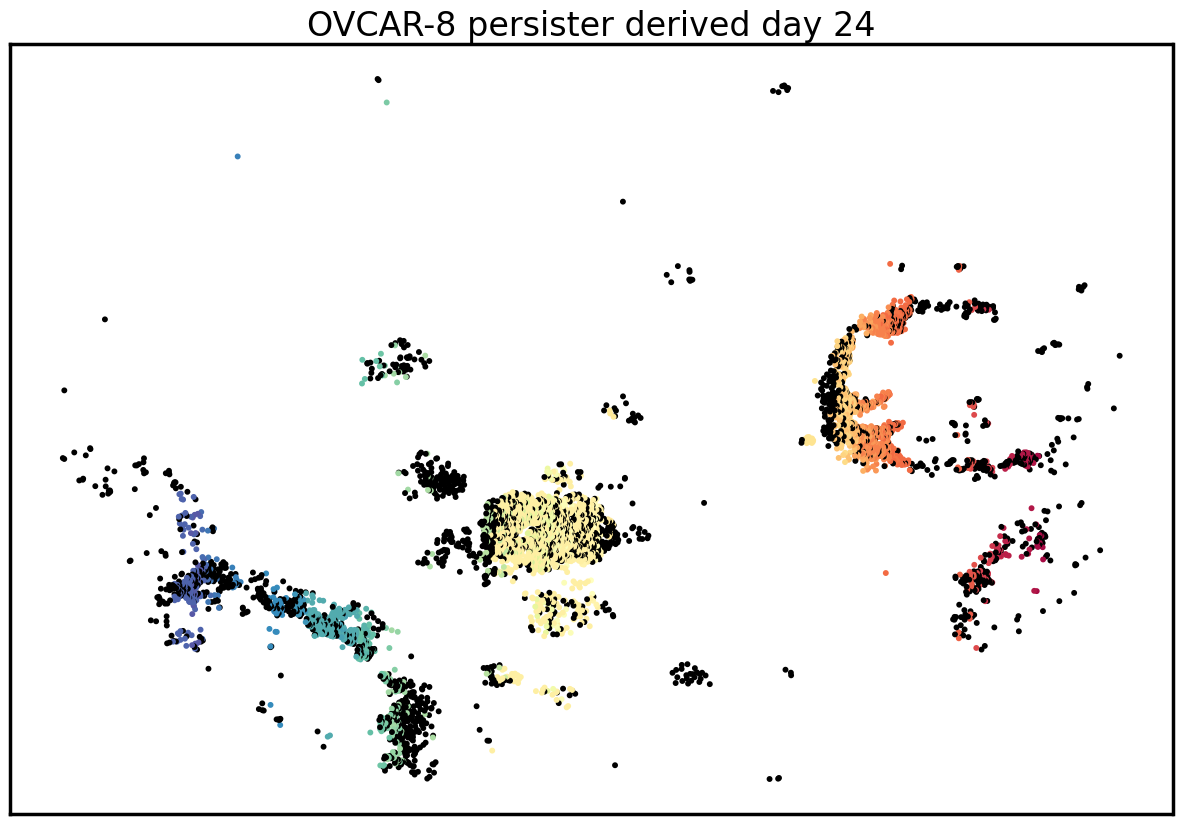

In [48]:
import numpy as np
import matplotlib.pyplot as plt

labels = day24["colony_id_clean"].values
unique_labels = np.unique(labels)

# assign a color to each label
colors_map = {
    lab: plt.cm.Spectral(i / len(unique_labels))
    for i, lab in enumerate(unique_labels)
}

# override noise (-1) to black
colors_map[-1] = (0, 0, 0, 1)

# build color list per point
colors = [colors_map[lab] for lab in labels]

plt.figure(figsize=(15,10))

plt.scatter(
    day24["i"],
    day24["j"],
    c=colors,
    s=5
)

plt.xticks([])
plt.yticks([])
plt.title("OVCAR-8 persister derived day 24")

plt.gca().invert_xaxis()
plt.show()

In [47]:
def plot_clusters(data, algorithm, args, kwds):
    start_time = time.time()
    labels = algorithm(*args, **kwds).fit_predict(data)
    end_time = time.time()
    palette = sns.color_palette('deep', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters found by {}'.format(str(algorithm.__name__)), fontsize=24)
    plt.text(-0.5, 0.7, 'Clustering took {:.2f} s'.format(end_time - start_time), fontsize=14)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
dbs = DBSCAN(eps=0.3)
for idx, scale in enumerate([1, 0.5, 3]):
    dbs.fit(X * scale)
    plot(X * scale, dbs.labels_, parameters={"scale": scale, "eps": 0.3}, ax=axes[idx])

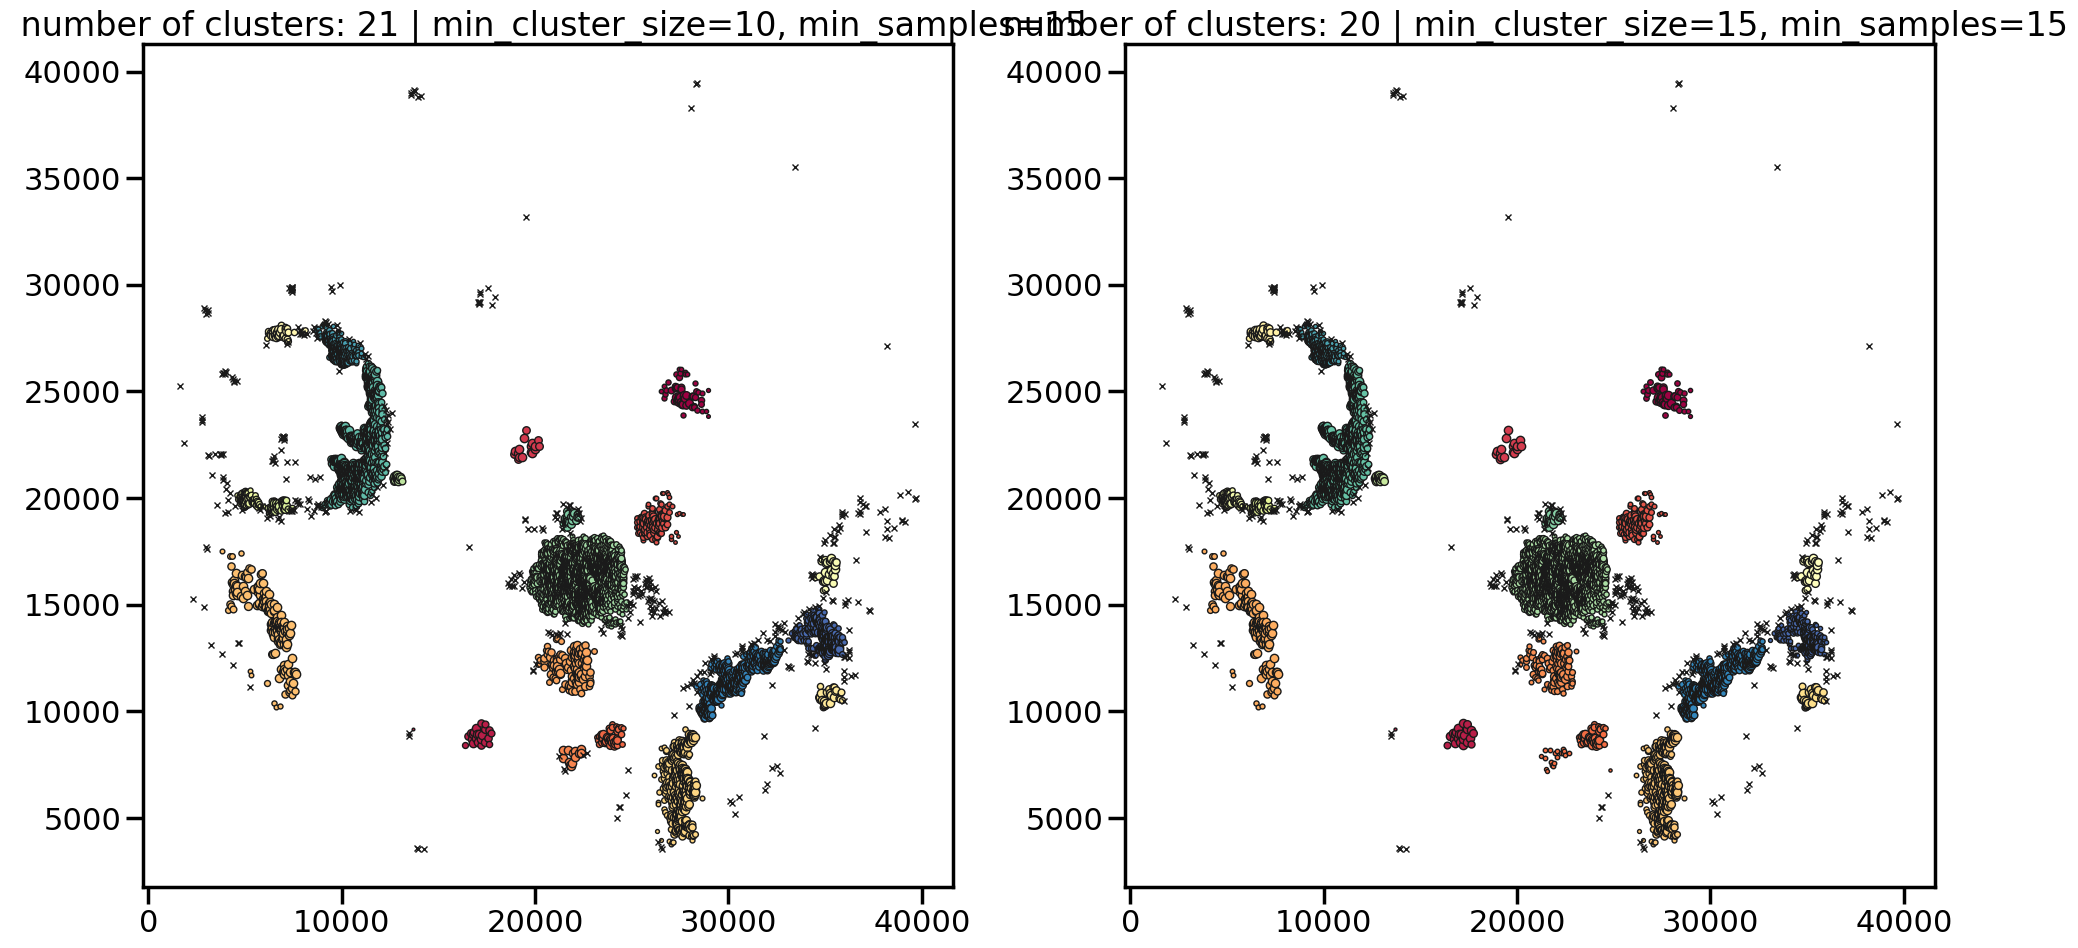

In [45]:
PARAM = ({"min_cluster_size": 10, "min_samples": 15}, {"min_cluster_size": 15, "min_samples": 15})
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for i, param in enumerate(PARAM):
    hdb = sklearn.cluster.HDBSCAN(copy=True, **param).fit(coords)
    labels = hdb.labels_

    plot(X, labels, hdb.probabilities_, param, ax=axes[i], hide=False)

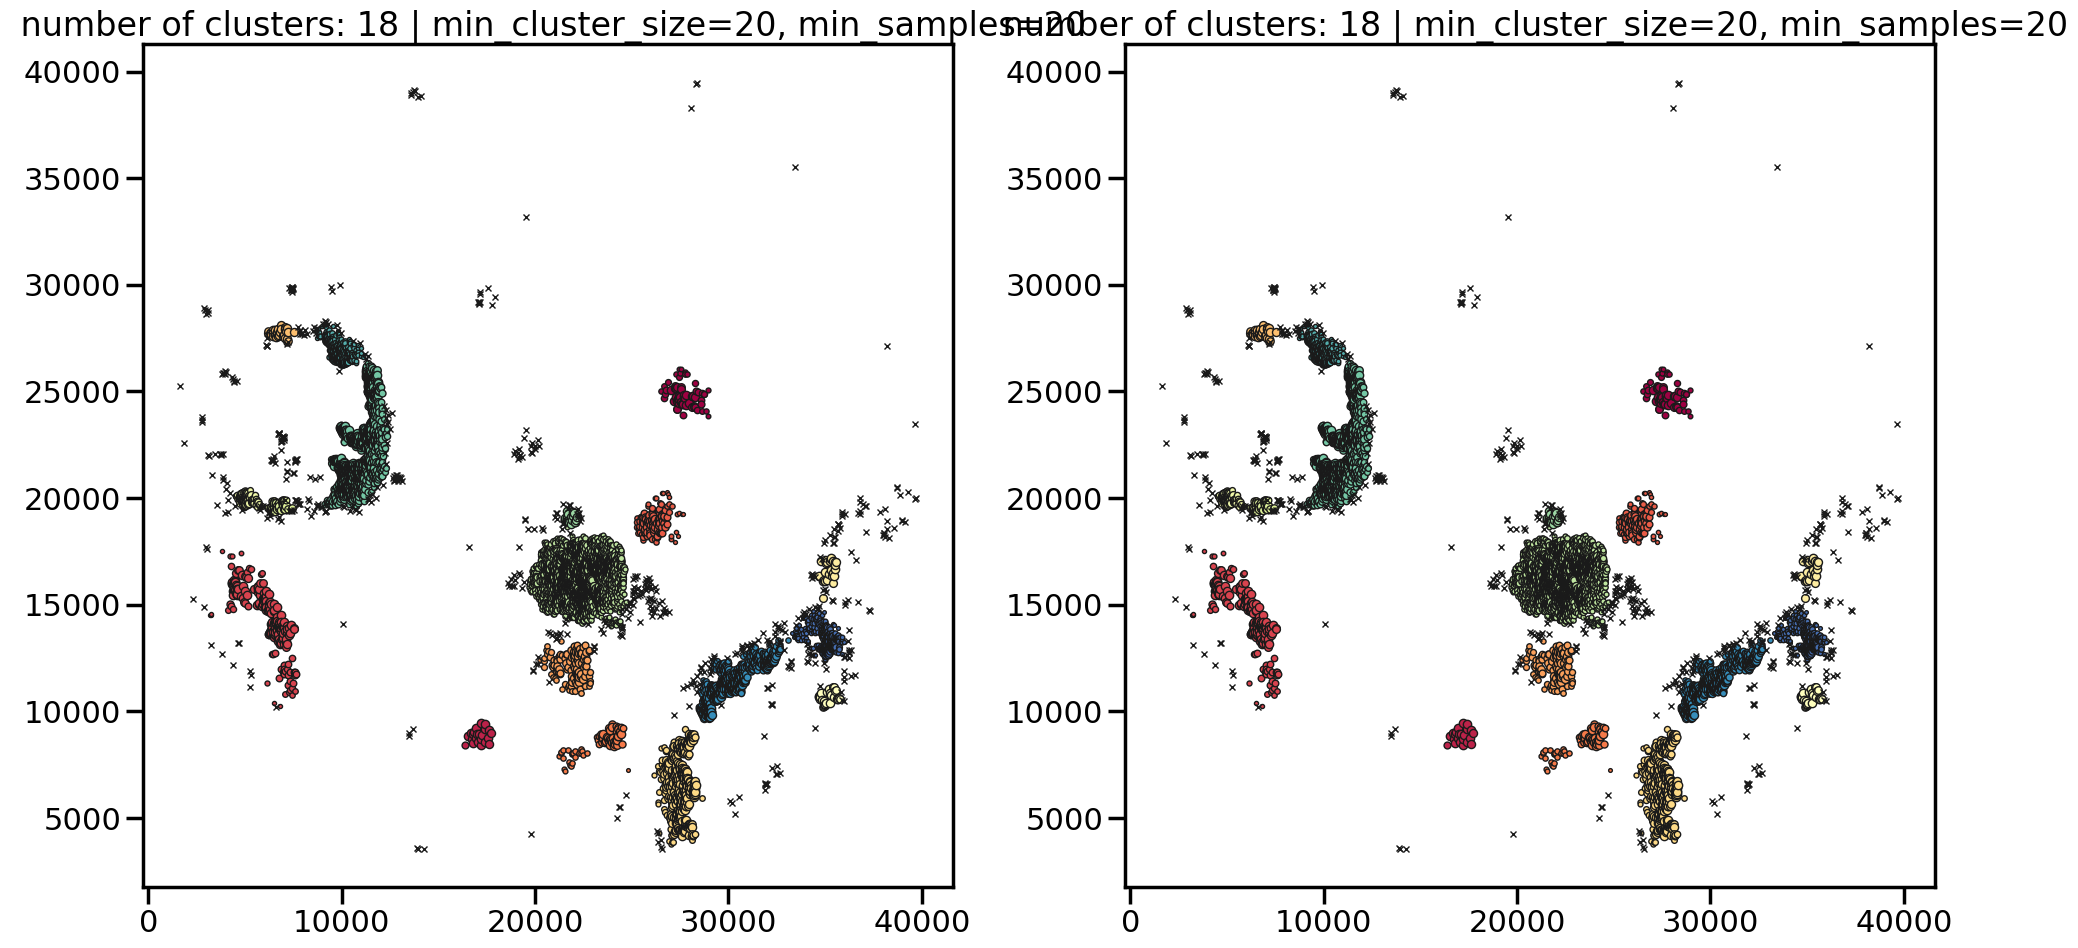

In [ ]:
PARAM = {"min_cluster_size": 10, "min_samples": 10}

fig, axes = plt.subplots(ncols=2, figsize=(20, 10))

hdb = sklearn.cluster.HDBSCAN(copy=True, **PARAM).fit(coords)
labels = hdb.labels_
day24["colony_labels_v2"] = hdb.labels_
day24["cluster_prob"] = hdb.probabilities_

plot(X, labels, hdb.probabilities_, PARAM, ax=axes[0], hide=False)
plot(X, day24["colony_labels_v2"].values, day24["cluster_prob"].values, PARAM, ax=axes[1], hide=False)

In [68]:
std_by_colony = day24.groupby("colony_labels")["nucleus_intensity_mean"].std()

day24["colony_id_clean"] = day24["colony_labels"].where(
    day24["colony_labels"].map(std_by_colony) < 1000,
    -1
)

In [104]:
day24["colony_labels_v2"] = day24["colony_labels"].where(
    day24["cluster_prob"] > 0.8,
    -1
)
day24.groupby("colony_labels_v2")["nucleus_intensity_mean"].describe()

,count,mean,std,min,25%,50%,75%,max
colony_labels_v2,,,,,,,,
-1,1681.0,1486.306936,1366.956145,9.922608,512.145833,1149.689523,1997.562523,16202.689600
0,35.0,2827.840881,859.249680,371.684914,2275.917295,2608.504065,3471.289975,4493.043358
1,22.0,328.271336,68.013915,237.263274,279.989597,306.123613,375.987922,453.471536
2,54.0,1429.901720,763.333062,718.162760,1006.443530,1200.026981,1406.456627,4311.029716
3,34.0,1410.071279,412.969509,838.379608,1124.429580,1296.163055,1572.464193,2459.872592
6,63.0,244.023115,95.929994,147.907168,172.567238,213.460967,278.011213,585.291196
8,298.0,793.856664,483.348615,325.765749,490.020106,626.565372,812.846721,2837.963840
9,81.0,1210.569999,512.884366,277.851920,932.003043,1230.409507,1430.467436,3651.922523
10,31.0,2425.667351,2098.714590,731.269982,1323.099491,1769.638338,2478.728540,10519.352829


In [108]:
std_by_colony2 = day24.groupby("colony_labels_v2")["nucleus_intensity_mean"].std()

day24["colony_id_clean_v2"] = day24["colony_labels_v2"].where(
    day24["colony_labels_v2"].map(std_by_colony2) < 900,
    -1
)

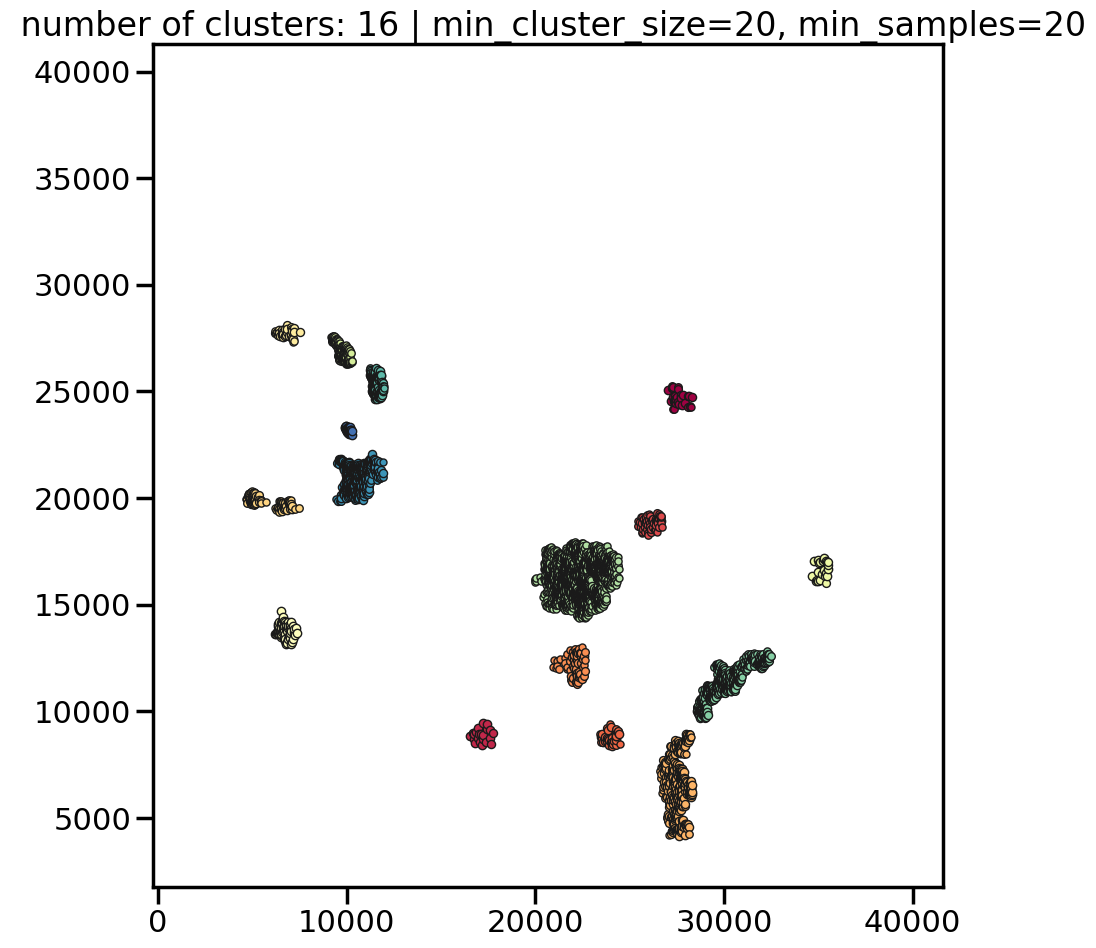

In [109]:
PARAM = {"min_cluster_size": 20, "min_samples": 20}

fig, axes = plt.subplots(figsize=(10, 10))


plot(X, day24["colony_id_clean_v2"].values, day24["cluster_prob"].values, PARAM, ax = axes, hide=True)

In [143]:
colony_stats = (
    day24[day24["in_colony"]]
    .groupby("colony_id")
    .agg(
        size=("foci_count", "size"),
        mean_foci=("foci_count", "mean"),
        median_foci=("foci_count", "median"),
        var_foci=("foci_count", "var"),
    )
)

log_colony_stats = (
    day24[day24["in_colony"]]
    .groupby("colony_id")
    .agg(
        size=("log_foci", "size"),
        mean_foci=("log_foci", "mean"),
        median_foci=("log_foci", "median"),
        var_foci=("log_foci", "var"),
    )
)

all_stats = (
    day24
    .groupby("colony_id")
    .agg(
        size=("foci_count", "size"),
        mean_foci=("foci_count", "mean"),
        median_foci=("foci_count", "median"),
        var_foci=("foci_count", "var"),
    )
)

log_all_stats = (
    day24
    .groupby("colony_id")
    .agg(
        size=("log_foci", "size"),
        mean_foci=("log_foci", "mean"),
        median_foci=("log_foci", "median"),
        var_foci=("log_foci", "var"),
    )
)

<Axes: xlabel='mean_foci', ylabel='var_foci'>

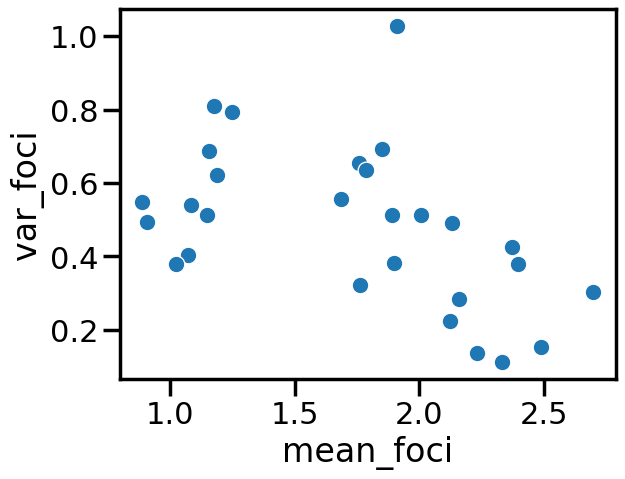

In [140]:
sns.scatterplot(
    data=log_colony_stats,
    x="mean_foci",
    y="var_foci"
)

<Axes: xlabel='size', ylabel='mean_foci'>

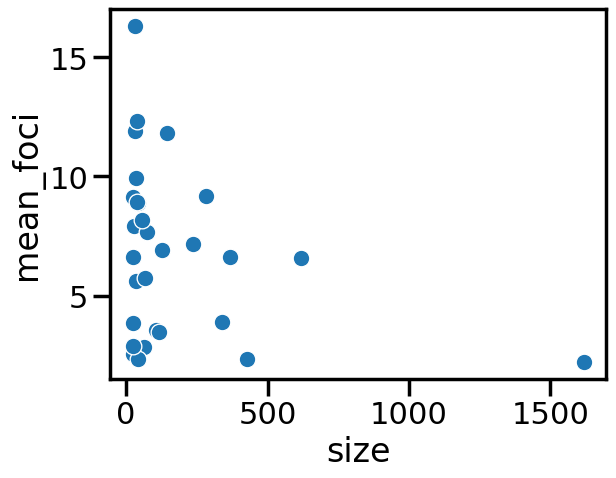

In [144]:
sns.scatterplot(
    data= all_stats,
    x="size",
    y="mean_foci"
)

<Axes: xlabel='colony_id', ylabel='mean_foci'>

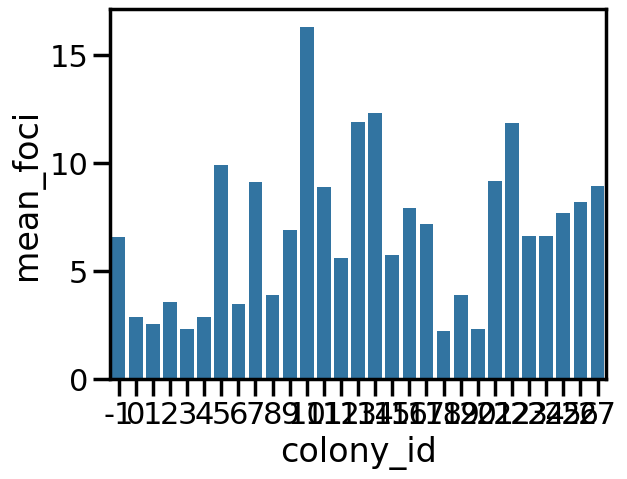

In [151]:
sns.barplot(all_stats["mean_foci"])

In [99]:
day24["in_colony"] = day24["colony_v2"].copy() != -1

<Axes: xlabel='size', ylabel='mean_foci'>

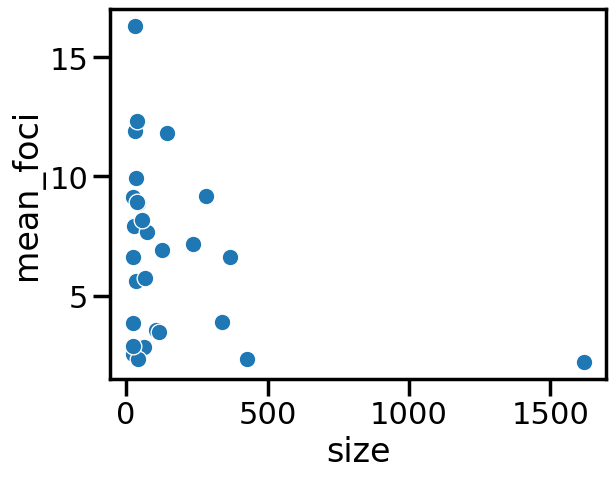

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    day24["i"],
    day24["j"],
    c=day24["foci_count"],
    s=5,
    cmap="inferno"
)

plt.gca().invert_yaxis()
plt.title("DNA damage spatial map")